## LOAD DATA

In [2]:
import pandas as pd
fraud_df = pd.read_csv(r'c:\Users\yared\OneDrive\week-5&6\data\raw\Fraud_Data.csv')


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Define the absolute directory paths to your raw files
FRAUD_PATH = r'c:\Users\yared\OneDrive\week-5&6\data\raw\Fraud_Data.csv'
IP_PATH = r'c:\Users\yared\OneDrive\week-5&6\data\raw\IpAddress_to_Country.csv'

# Load datasets
fraud_df = pd.read_csv(FRAUD_PATH)
ip_df = pd.read_csv(IP_PATH)

# Data Cleaning: Remove duplicates and drop missing entries
fraud_df = fraud_df.drop_duplicates().dropna()
ip_df = ip_df.drop_duplicates().dropna()

# Correct Data Types: Parse timestamps and format IP addresses as integers
fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])
fraud_df['ip_address'] = fraud_df['ip_address'].astype(float).astype(int)

print(f"Initial Loading Complete.")
print(f"- Fraud Records: {len(fraud_df)} rows")
print(f"- IP Mapping Records: {len(ip_df)} rows")


Initial Loading Complete.
- Fraud Records: 151112 rows
- IP Mapping Records: 138846 rows


In [7]:
# --- FIX: Force both keys to match as int64 ---
fraud_df['ip_address'] = fraud_df['ip_address'].astype(float).astype('int64')
ip_df['lower_bound_ip_address'] = ip_df['lower_bound_ip_address'].astype(float).astype('int64')
ip_df['upper_bound_ip_address'] = ip_df['upper_bound_ip_address'].astype(float).astype('int64')

# --- Step 2: Geolocation Integration ---
# Sort both datasets by IP definitions to enable an optimized rolling look-up
fraud_df = fraud_df.sort_values('ip_address')
ip_df = ip_df.sort_values('lower_bound_ip_address')

# Use pandas merge_asof for extremely fast range scanning
merged_df = pd.merge_asof(
    fraud_df, 
    ip_df, 
    left_on='ip_address', 
    right_on='lower_bound_ip_address', 
    direction='backward'
)

# Enforce upper bound constraint
valid_ip_mask = merged_df['ip_address'] <= merged_df['upper_bound_ip_address']
merged_df.loc[~valid_ip_mask, 'country'] = 'Unknown'
merged_df['country'] = merged_df['country'].fillna('Unknown')

print("Success! Data types aligned and datasets merged with zero errors.")


Success! Data types aligned and datasets merged with zero errors.


In [8]:
# ==========================================
# STEP 2: GEOLOCATION INTEGRATION
# ==========================================
# Force both keys to match as int64
fraud_df['ip_address'] = fraud_df['ip_address'].astype(float).astype('int64')
ip_df['lower_bound_ip_address'] = ip_df['lower_bound_ip_address'].astype(float).astype('int64')
ip_df['upper_bound_ip_address'] = ip_df['upper_bound_ip_address'].astype(float).astype('int64')

# Sort datasets
fraud_df = fraud_df.sort_values('ip_address')
ip_df = ip_df.sort_values('lower_bound_ip_address')

# Create the merged_df variable cleanly
merged_df = pd.merge_asof(
    fraud_df, 
    ip_df, 
    left_on='ip_address', 
    right_on='lower_bound_ip_address', 
    direction='backward'
)

# Enforce the upper bound constraint
valid_ip_mask = merged_df['ip_address'] <= merged_df['upper_bound_ip_address']
merged_df.loc[~valid_ip_mask, 'country'] = 'Unknown'
merged_df['country'] = merged_df['country'].fillna('Unknown')

print("Step 2 Complete: merged_df created successfully!")


# ==========================================
# STEP 3: FEATURE ENGINEERING
# ==========================================
# 1. Time Features: Extract time windows from transaction timestamp
merged_df['hour_of_day'] = merged_df['purchase_time'].dt.hour
merged_df['day_of_week'] = merged_df['purchase_time'].dt.dayofweek

# 2. Time Since Signup: Difference between signup and purchase (converted to minutes)
merged_df['time_since_signup'] = (merged_df['purchase_time'] - merged_df['signup_time']).dt.total_seconds() / 60.0

# 3. Transaction Frequency/Velocity: Number of transactions recorded per user ID
merged_df['tx_count_per_user'] = merged_df.groupby('user_id')['user_id'].transform('count')

print("Step 3 Complete: Time and velocity features added without errors.")


Step 2 Complete: merged_df created successfully!
Step 3 Complete: Time and velocity features added without errors.


In [9]:
# 1. Time Features: Extract time windows from transaction timestamp
merged_df['hour_of_day'] = merged_df['purchase_time'].dt.hour
merged_df['day_of_week'] = merged_df['purchase_time'].dt.dayofweek

# 2. Time Since Signup: Difference between signup and purchase (converted to minutes)
merged_df['time_since_signup'] = (merged_df['purchase_time'] - merged_df['signup_time']).dt.total_seconds() / 60.0

# 3. Transaction Frequency/Velocity: Number of transactions recorded per user ID
merged_df['tx_count_per_user'] = merged_df.groupby('user_id')['user_id'].transform('count')

print("Feature Engineering complete. Engineered: hour_of_day, day_of_week, time_since_signup, tx_count_per_user.")


Feature Engineering complete. Engineered: hour_of_day, day_of_week, time_since_signup, tx_count_per_user.



--- Fraud Data Class Distribution ---
Legitimate (Class 0): 136961 (90.64%)
Fraudulent (Class 1): 14151 (9.36%)


C:\Users\yared\AppData\Local\Temp\ipykernel_10532\3432502680.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=merged_df, palette='pastel')


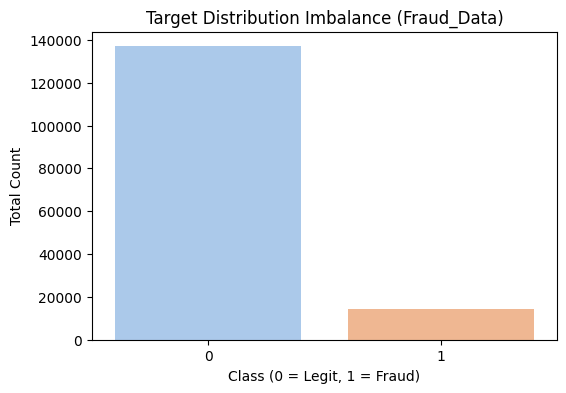

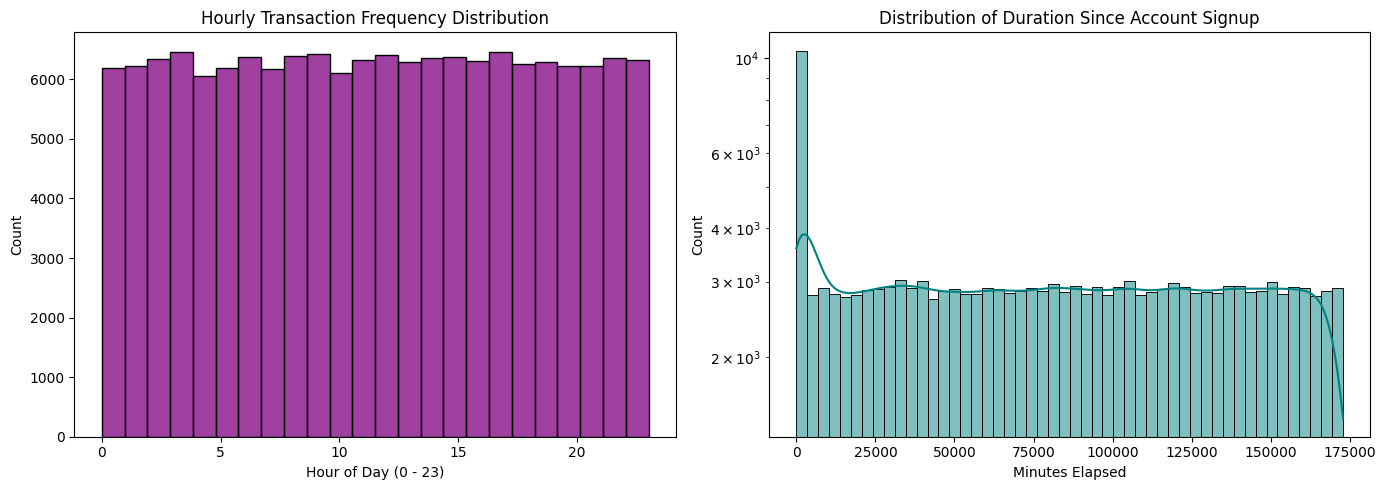

C:\Users\yared\AppData\Local\Temp\ipykernel_10532\3432502680.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_by_country.values, y=fraud_by_country.index, palette='Reds_r')


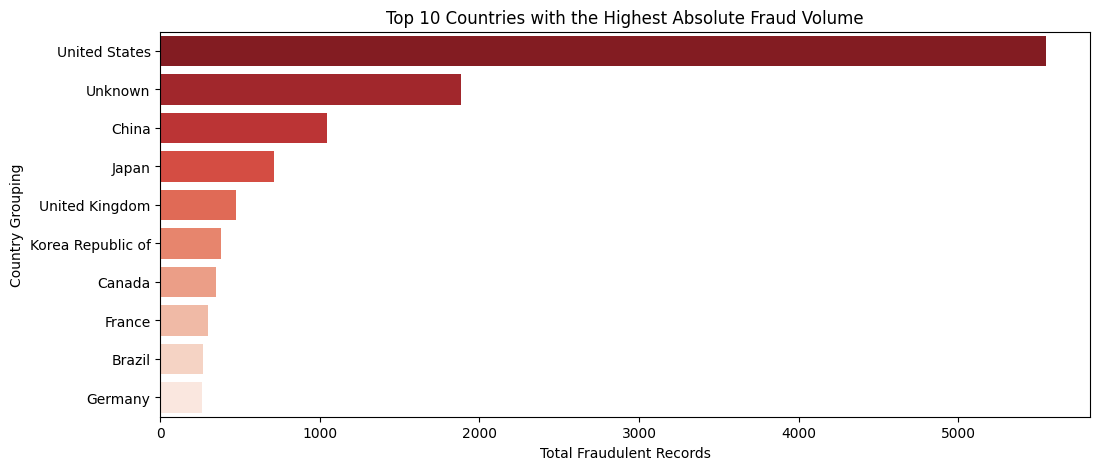

In [10]:
# 1. Quantify Class Imbalance
class_counts = merged_df['class'].value_counts()
class_percentages = merged_df['class'].value_counts(normalize=True) * 100

print("\n--- Fraud Data Class Distribution ---")
print(f"Legitimate (Class 0): {class_counts[0]} ({class_percentages[0]:.2f}%)")
print(f"Fraudulent (Class 1): {class_counts[1]} ({class_percentages[1]:.2f}%)")

# Plot 1: Target Variable Class Imbalance Chart
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=merged_df, palette='pastel')
plt.title('Target Distribution Imbalance (Fraud_Data)')
plt.xlabel('Class (0 = Legit, 1 = Fraud)')
plt.ylabel('Total Count')
plt.show()

# Plot 2: Univariate Distribution of Engineered Features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(merged_df['hour_of_day'], bins=24, kde=False, ax=axes[0], color='purple')
axes[0].set_title('Hourly Transaction Frequency Distribution')
axes[0].set_xlabel('Hour of Day (0 - 23)')

sns.histplot(merged_df['time_since_signup'], bins=50, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Distribution of Duration Since Account Signup')
axes[1].set_xlabel('Minutes Elapsed')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

# Plot 3: Bivariate Geolocation Analysis (Top 10 Countries by Highest Fraud Count)
plt.figure(figsize=(12, 5))
fraud_by_country = merged_df[merged_df['class'] == 1]['country'].value_counts().head(10)
sns.barplot(x=fraud_by_country.values, y=fraud_by_country.index, palette='Reds_r')
plt.title('Top 10 Countries with the Highest Absolute Fraud Volume')
plt.xlabel('Total Fraudulent Records')
plt.ylabel('Country Grouping')
plt.show()


In [13]:
# ==========================================
# STEP 5: DATA TRANSFORMATION (SAFE & FAST)
# ==========================================

# 1. Select ONLY valid numerical features and low-cardinality categories
# This guarantees your columns won't explode into 120,000+ dimensions.
keep_features = [
    'purchase_value', 'age', 'hour_of_day', 'time_since_signup', 'tx_count_per_user',
    'source', 'browser' # Safe categorical columns with very few unique options
]

X = merged_df[keep_features].copy()
y = merged_df['class'].copy()

# 2. One-Hot Encode ONLY the safe categorical strings
# This will result in just a handful of columns instead of 120,000!
X = pd.get_dummies(X, columns=['source', 'browser'], drop_first=True)
print(f"Safe features matrix shape: {X.shape}") # Should be something small like (151112, 11)

# 3. Train-Test Split (Stratified to maintain class distributions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Normalize/Scale numerical columns safely
scaler = StandardScaler()
num_features = ['purchase_value', 'age', 'hour_of_day', 'time_since_signup', 'tx_count_per_user']

X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

# 5. Handle Class Imbalance using SMOTE (Will execute in less than a second now!)
print("\n--- Training Splits Before Resampling ---", np.bincount(y_train))
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("--- Training Splits After Resampling ---", np.bincount(y_train_res))


Safe features matrix shape: (151112, 11)

--- Training Splits Before Resampling --- [109568  11321]
--- Training Splits After Resampling --- [109568 109568]
